# Drift Prediction - Burn-in Data

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import RandomizedSearchCV, GroupKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Config

In [2]:
CSV_PATH = "burn_in_dataset.csv"
SPLIT_PATH = "component_split.csv"

CHECKPOINTS = ['0h', '24h', '96h', '168h']
FEATURE_CHECKPOINTS = ['0h', '24h']
TARGET_CHECKPOINTS = ['96h', '168h']
METRICS = ['Leakage', 'Resistance', 'Vth']

STRESS_COL = 'Proxy_Stress'
STRESS_LEVEL_COL = 'Stress_Level'
PART_TYPE_COL = 'Part_Type'
LABEL_COL = 'Label'
BATCH_COL = 'Batch_ID'
TIMESTAMP_PREFIX = 'Timestamp_'

## Load + clean

In [3]:
df = pd.read_csv(CSV_PATH)
split = pd.read_csv(SPLIT_PATH)
df = df.merge(split[['Component_ID','split']], on='Component_ID')
print(df.shape)

reading_cols = [f'{m}_{cp}' for m in METRICS for cp in CHECKPOINTS]
for col in reading_cols:
    bad_count = (df[col] < 0).sum()
    if bad_count:
        print(f'{col}: {bad_count} bad sensor readings')
    df.loc[df[col] < 0, col] = np.nan

target_cols_raw = [f'{m}_{cp}' for m in METRICS for cp in TARGET_CHECKPOINTS]
feature_cols_raw = [f'{m}_{cp}' for m in METRICS for cp in FEATURE_CHECKPOINTS]

before = len(df)
df = df.dropna(subset=target_cols_raw).reset_index(drop=True)
print(f'dropped {before - len(df)} rows with missing/bad targets, {len(df)} remain')

(10000, 26)
Leakage_24h: 53 bad sensor readings
Leakage_96h: 52 bad sensor readings
Leakage_168h: 46 bad sensor readings
Resistance_24h: 46 bad sensor readings
Resistance_96h: 52 bad sensor readings
Resistance_168h: 52 bad sensor readings
Vth_24h: 36 bad sensor readings
Vth_96h: 56 bad sensor readings
Vth_168h: 53 bad sensor readings
dropped 1128 rows with missing/bad targets, 8872 remain


In [4]:
for cp in CHECKPOINTS:
    df[f'{TIMESTAMP_PREFIX}{cp}'] = pd.to_datetime(df[f'{TIMESTAMP_PREFIX}{cp}'], format='ISO8601')
for cp in FEATURE_CHECKPOINTS[1:] + TARGET_CHECKPOINTS:
    df[f'elapsed_{cp}'] = (df[f'{TIMESTAMP_PREFIX}{cp}'] - df[f'{TIMESTAMP_PREFIX}0h']).dt.total_seconds() / 3600
df[['elapsed_24h','elapsed_96h','elapsed_168h']].describe()

,elapsed_24h,elapsed_96h,elapsed_168h
count,8872.000000,8872.000000,8872.000000
mean,24.006377,95.998204,168.007740
std,0.398241,0.599730,0.597264
min,22.479468,93.840824,165.762810
25%,23.735933,95.591060,167.608098
50%,24.003274,95.999688,168.001955
75%,24.270594,96.405456,168.408662
max,25.446475,98.088478,170.398831


## Reuse the shared, Batch_ID-grouped train/val/test split


In [5]:
idx_train = df.index[df['split'] == 'train']
idx_val   = df.index[df['split'] == 'val']
idx_test  = df.index[df['split'] == 'test']
label_train, label_val, label_test = df.loc[idx_train, LABEL_COL], df.loc[idx_val, LABEL_COL], df.loc[idx_test, LABEL_COL]
print(len(idx_train), 'train /', len(idx_val), 'val /', len(idx_test), 'test')

assert set(df.loc[idx_train, BATCH_COL]) & set(df.loc[idx_test, BATCH_COL]) == set(), 'train/test batch overlap!'
assert set(df.loc[idx_train, BATCH_COL]) & set(df.loc[idx_val, BATCH_COL]) == set(), 'train/val batch overlap!'

5793 train / 1639 val / 1440 test


In [6]:
imputer = SimpleImputer(strategy='median')
imputer.fit(df.loc[idx_train, feature_cols_raw])
df.loc[:, feature_cols_raw] = imputer.transform(df[feature_cols_raw])


## Features + targets


In [7]:
df['Leakage_slope'] = (df['Leakage_24h'] - df['Leakage_0h']) / df['elapsed_24h']
df['Resistance_slope'] = (df['Resistance_24h'] - df['Resistance_0h']) / df['elapsed_24h']
df['Vth_slope'] = (df['Vth_24h'] - df['Vth_0h']) / df['elapsed_24h']

feature_cols_num = feature_cols_raw + [STRESS_LEVEL_COL, 'elapsed_24h', 'Leakage_slope', 'Resistance_slope', 'Vth_slope']
cat_cols = [STRESS_COL, PART_TYPE_COL]

X_train_raw = pd.get_dummies(df.loc[idx_train, feature_cols_num + cat_cols], columns=cat_cols)
train_columns = X_train_raw.columns
X = pd.get_dummies(df[feature_cols_num + cat_cols], columns=cat_cols).reindex(columns=train_columns, fill_value=0)

y = pd.DataFrame(index=df.index)
y['Leakage_96h_log'] = np.log1p(df['Leakage_96h'])
y['Leakage_168h_log'] = np.log1p(df['Leakage_168h'])
y['Resistance_96h_delta'] = df['Resistance_96h'] - df['Resistance_24h']
y['Resistance_168h_delta'] = df['Resistance_168h'] - df['Resistance_24h']
y['Vth_96h_delta'] = df['Vth_96h'] - df['Vth_24h']
y['Vth_168h_delta'] = df['Vth_168h'] - df['Vth_24h']

def reconstruct(raw_preds, idx):
    out = pd.DataFrame(index=idx)
    out['Leakage_96h'] = np.expm1(raw_preds[:, 0])
    out['Leakage_168h'] = np.expm1(raw_preds[:, 1])
    out['Resistance_96h'] = df.loc[idx, 'Resistance_24h'].values + raw_preds[:, 2]
    out['Resistance_168h'] = df.loc[idx, 'Resistance_24h'].values + raw_preds[:, 3]
    out['Vth_96h'] = df.loc[idx, 'Vth_24h'].values + raw_preds[:, 4]
    out['Vth_168h'] = df.loc[idx, 'Vth_24h'].values + raw_preds[:, 5]
    return out[target_cols_raw]

X_train, X_val, X_test = X.loc[idx_train], X.loc[idx_val], X.loc[idx_test]
y_train, y_val, y_test = y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]
y_val_actual = df.loc[idx_val, target_cols_raw]
y_test_actual = df.loc[idx_test, target_cols_raw]

def evaluate(y_true, y_pred, name):
    print(f'--- {name} ---')
    for col in target_cols_raw:
        mae = mean_absolute_error(y_true[col], y_pred[col])
        print(f'{col:16s} MAE={mae:.4f}')
    print()

X.shape

(8872, 18)

## Baseline (reported on VAL for model selection and TEST for the final number)

In [8]:
def baseline_predict(idx):
    preds = pd.DataFrame(index=idx)
    for m in METRICS:
        v0 = df.loc[idx, f'{m}_0h']; v24 = df.loc[idx, f'{m}_24h']
        slope = (v24 - v0) / df.loc[idx, 'elapsed_24h']
        preds[f'{m}_96h'] = v24 + slope * (df.loc[idx, 'elapsed_96h'] - df.loc[idx, 'elapsed_24h'])
        preds[f'{m}_168h'] = v24 + slope * (df.loc[idx, 'elapsed_168h'] - df.loc[idx, 'elapsed_24h'])
    return preds[target_cols_raw]

baseline_val_preds = baseline_predict(idx_val)
evaluate(y_val_actual, baseline_val_preds, 'Baseline (VAL)')

--- Baseline (VAL) ---
Leakage_96h      MAE=0.2955
Leakage_168h     MAE=0.5181
Resistance_96h   MAE=2.4672
Resistance_168h  MAE=5.0037
Vth_96h          MAE=0.0368
Vth_168h         MAE=0.0713



## RF + GB, tuned



In [9]:
groups_train = df.loc[idx_train, BATCH_COL].values
gkf = GroupKFold(n_splits=3)

rf_grid = {'n_estimators': [150, 250], 'max_depth': [15, 25, None], 'min_samples_leaf': [1, 2, 4]}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_grid,
                                n_iter=6, cv=gkf, scoring='neg_mean_absolute_error', random_state=42, n_jobs=1)
rf_search.fit(X_train, y_train, groups=groups_train)
rf_tuned = rf_search.best_estimator_
print('best RF params:', rf_search.best_params_)
evaluate(y_val_actual, reconstruct(rf_tuned.predict(X_val), idx_val), 'Random Forest tuned (VAL)')

best RF params: {'n_estimators': 250, 'min_samples_leaf': 4, 'max_depth': 15}
--- Random Forest tuned (VAL) ---
Leakage_96h      MAE=0.1593
Leakage_168h     MAE=0.2534
Resistance_96h   MAE=0.8976
Resistance_168h  MAE=1.7642
Vth_96h          MAE=0.0106
Vth_168h         MAE=0.0163



In [10]:
gb_grid = {'estimator__n_estimators': [100, 150], 'estimator__learning_rate': [0.05, 0.1], 'estimator__max_depth': [2, 3]}
gb_search = RandomizedSearchCV(MultiOutputRegressor(GradientBoostingRegressor(random_state=42)), gb_grid,
                                n_iter=5, cv=gkf, scoring='neg_mean_absolute_error', random_state=42, n_jobs=1)
gb_search.fit(X_train, y_train, groups=groups_train)
gb_tuned = gb_search.best_estimator_
print('best GB params:', gb_search.best_params_)
evaluate(y_val_actual, reconstruct(gb_tuned.predict(X_val), idx_val), 'Gradient Boosting tuned (VAL)')

best GB params: {'estimator__n_estimators': 150, 'estimator__max_depth': 2, 'estimator__learning_rate': 0.05}
--- Gradient Boosting tuned (VAL) ---
Leakage_96h      MAE=0.1030
Leakage_168h     MAE=0.1913
Resistance_96h   MAE=0.8586
Resistance_168h  MAE=1.6806
Vth_96h          MAE=0.0099
Vth_168h         MAE=0.0156



## Tried: weighting Fail/Borderline samples higher


In [11]:
weight_options = [
    {'Safe': 1, 'Borderline': 2, 'Fail': 3},
    {'Safe': 1, 'Borderline': 5, 'Fail': 15},
]

for weights in weight_options:
    sw = label_train.map(weights).values
    rf_w = RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_leaf=4, random_state=42, n_jobs=-1)
    rf_w.fit(X_train, y_train, sample_weight=sw)
    preds = reconstruct(rf_w.predict(X_val), idx_val)

    check = pd.DataFrame({'label': label_val.values, 'true': y_val_actual['Leakage_168h'].values, 'pred': preds['Leakage_168h'].values})
    check['err'] = (check['true'] - check['pred']).abs()
    print('weights:', weights)
    print(check.groupby('label', observed=True)['err'].mean())
    print('overall MAE (VAL):', round(mean_absolute_error(y_val_actual['Leakage_168h'], preds['Leakage_168h']), 4))
    print()

weights: {'Safe': 1, 'Borderline': 2, 'Fail': 3}
label
Borderline    0.258994
Fail          0.776666
Safe          0.143087
Name: err, dtype: float64
overall MAE (VAL): 0.2719

weights: {'Safe': 1, 'Borderline': 5, 'Fail': 15}
label
Borderline    0.291054
Fail          0.795080
Safe          0.238536
Name: err, dtype: float64
overall MAE (VAL): 0.3423



## Stacked ensemble



In [12]:
gkf4 = GroupKFold(n_splits=4)

rf_base = RandomForestRegressor(n_estimators=250, max_depth=15, min_samples_leaf=4, random_state=42, n_jobs=-1)
gb_base = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=150, max_depth=2, learning_rate=0.05, random_state=42))

rf_oof = cross_val_predict(rf_base, X_train, y_train, cv=gkf4, groups=groups_train, n_jobs=1)
gb_oof = cross_val_predict(gb_base, X_train, y_train, cv=gkf4, groups=groups_train, n_jobs=1)

meta_X_train = np.hstack([rf_oof, gb_oof])
meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_X_train, y_train)

rf_base.fit(X_train, y_train)
gb_base.fit(X_train, y_train)

meta_X_val = np.hstack([rf_base.predict(X_val), gb_base.predict(X_val)])
stacked_val_preds = reconstruct(meta_model.predict(meta_X_val), idx_val)
simple_avg_val_preds = reconstruct((rf_tuned.predict(X_val) + gb_tuned.predict(X_val)) / 2, idx_val)

evaluate(y_val_actual, simple_avg_val_preds, 'Simple average ensemble (VAL)')
evaluate(y_val_actual, stacked_val_preds, 'Stacked ensemble Ridge (VAL)')

--- Simple average ensemble (VAL) ---
Leakage_96h      MAE=0.1220
Leakage_168h     MAE=0.2115
Resistance_96h   MAE=0.8581
Resistance_168h  MAE=1.6926
Vth_96h          MAE=0.0102
Vth_168h         MAE=0.0157

--- Stacked ensemble Ridge (VAL) ---
Leakage_96h      MAE=0.1016
Leakage_168h     MAE=0.1910
Resistance_96h   MAE=0.8253
Resistance_168h  MAE=1.6263
Vth_96h          MAE=0.0100
Vth_168h         MAE=0.0156



In [13]:
meta_X_test = np.hstack([rf_base.predict(X_test), gb_base.predict(X_test)])
stacked_test_preds = reconstruct(meta_model.predict(meta_X_test), idx_test)
evaluate(y_test_actual, stacked_test_preds, 'Stacked ensemble Ridge (TEST - the number to trust)')

--- Stacked ensemble Ridge (TEST - the number to trust) ---
Leakage_96h      MAE=0.1057
Leakage_168h     MAE=0.2039
Resistance_96h   MAE=1.0756
Resistance_168h  MAE=1.6930
Vth_96h          MAE=0.0094
Vth_168h         MAE=0.0148



## Prediction intervals (quantile regression)

In [14]:
gb_lower = MultiOutputRegressor(GradientBoostingRegressor(loss='quantile', alpha=0.05, n_estimators=150, max_depth=3, random_state=42))
gb_upper = MultiOutputRegressor(GradientBoostingRegressor(loss='quantile', alpha=0.95, n_estimators=150, max_depth=3, random_state=42))
gb_lower.fit(X_train, y_train)
gb_upper.fit(X_train, y_train)

raw_lower = gb_lower.predict(X_test)
raw_upper = gb_upper.predict(X_test)
crossed = (raw_lower > raw_upper)
print('quantile-crossing cells corrected:', int(crossed.sum()), '/', crossed.size)
raw_lower, raw_upper = np.minimum(raw_lower, raw_upper), np.maximum(raw_lower, raw_upper)

lower_preds = reconstruct(raw_lower, idx_test)
upper_preds = reconstruct(raw_upper, idx_test)

for col in target_cols_raw:
    inside = (y_test_actual[col] >= lower_preds[col]) & (y_test_actual[col] <= upper_preds[col])
    print(f'{col:16s} coverage={inside.mean():.1%}  avg width={ (upper_preds[col]-lower_preds[col]).mean():.4f}')

quantile-crossing cells corrected: 1 / 8640
Leakage_96h      coverage=86.5%  avg width=0.3406
Leakage_168h     coverage=85.5%  avg width=0.6783
Resistance_96h   coverage=88.3%  avg width=2.1129
Resistance_168h  coverage=88.5%  avg width=3.3817
Vth_96h          coverage=87.8%  avg width=0.0315
Vth_168h         coverage=88.0%  avg width=0.0503


In [15]:
df_test = df.loc[idx_test].copy()
for m in METRICS:
    step = (df_test[f'{m}_168h'] - df_test[f'{m}_96h']).abs()
    typical = df.loc[idx_train, f'{m}_96h'].sub(df.loc[idx_train, f'{m}_24h']).abs().median()
    suspicious = (step > 10 * typical).values
    for target_col in [f'{m}_96h', f'{m}_168h']:
        width = (upper_preds[target_col] - lower_preds[target_col]).values
        if suspicious.sum() > 0:
            print(f'{target_col:16s} normal_avg_width={width[~suspicious].mean():.4f}  '
                  f'suspicious_avg_width={width[suspicious].mean():.4f}  (n_suspicious={suspicious.sum()})')
        else:
            print(f'{target_col:16s} no suspicious rows in this split')

Leakage_96h      normal_avg_width=0.3020  suspicious_avg_width=1.2270  (n_suspicious=60)
Leakage_168h     normal_avg_width=0.6226  suspicious_avg_width=1.9614  (n_suspicious=60)
Resistance_96h   normal_avg_width=2.1077  suspicious_avg_width=2.7245  (n_suspicious=12)
Resistance_168h  normal_avg_width=3.3648  suspicious_avg_width=5.3900  (n_suspicious=12)
Vth_96h          normal_avg_width=0.0311  suspicious_avg_width=0.0683  (n_suspicious=14)
Vth_168h         normal_avg_width=0.0497  suspicious_avg_width=0.1134  (n_suspicious=14)


## Explicit safety-slope early-rejection rule


In [16]:
def drift_rate(v24, v168, elapsed_24h, elapsed_168h):
    return (v168 - v24) / (elapsed_168h - elapsed_24h)

safe_train_mask = (label_train == 'Safe').values
safety_slope = {}
for m in METRICS:
    rate = drift_rate(
        df.loc[idx_train, f'{m}_24h'].values, df.loc[idx_train, f'{m}_168h'].values,
        df.loc[idx_train, 'elapsed_24h'].values, df.loc[idx_train, 'elapsed_168h'].values,
    )
    safety_slope[m] = float(np.percentile(np.abs(rate[safe_train_mask]), 99))
print('Safety slope thresholds (units/hour, from Safe TRAIN rows only):')
for m, v in safety_slope.items():
    print(f'  {m:12s} {v:.5f}')

pred_rate_test = pd.DataFrame(index=idx_test)
for m in METRICS:
    rate = drift_rate(
        df.loc[idx_test, f'{m}_24h'].values, stacked_test_preds[f'{m}_168h'].values,
        df.loc[idx_test, 'elapsed_24h'].values, df.loc[idx_test, 'elapsed_168h'].values,
    )
    pred_rate_test[m] = np.abs(rate)

slope_reject_flag = pd.Series(False, index=idx_test)
for m in METRICS:
    slope_reject_flag |= (pred_rate_test[m] > safety_slope[m])

print(f'\nEarly-rejection flag raised on {int(slope_reject_flag.sum())} / {len(slope_reject_flag)} TEST components')

fail_mask_test = (label_test == 'Fail').values
safe_mask_test = (label_test == 'Safe').values
if fail_mask_test.any():
    recall = slope_reject_flag.values[fail_mask_test].mean()
    print(f'Recall on true FAIL (this rule alone):        {recall:.1%}')
false_alarm = slope_reject_flag.values[safe_mask_test].mean()
print(f'False-alarm rate on true SAFE (this rule alone): {false_alarm:.1%}')

Safety slope thresholds (units/hour, from Safe TRAIN rows only):
  Leakage      0.00650
  Resistance   0.03687
  Vth          0.00049

Early-rejection flag raised on 233 / 1440 TEST components
Recall on true FAIL (this rule alone):        58.8%
False-alarm rate on true SAFE (this rule alone): 2.7%


## Which features matter (from RF)

In [23]:
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

,0
Resistance_slope,0.247790
Vth_slope,0.169919
Leakage_slope,0.145424
elapsed_24h,0.081328
Stress_Level,0.068988
Leakage_0h,0.062457
Resistance_24h,0.051030
Leakage_24h,0.046444
Resistance_0h,0.041003
Vth_0h,0.036706


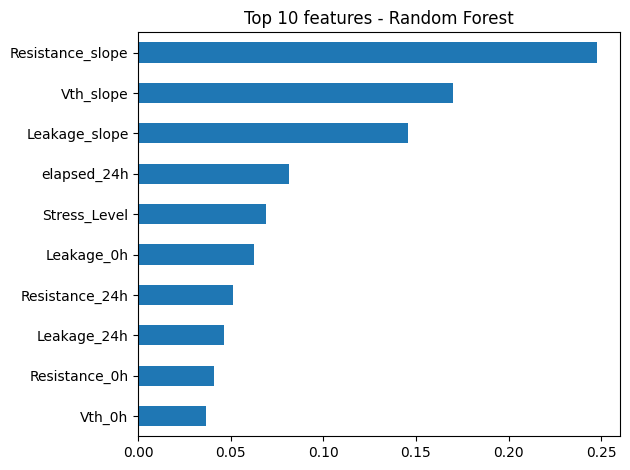

In [24]:
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 features - Random Forest')
plt.tight_layout()
plt.show()

## Error by label (TEST, the final model)

In [25]:
check = pd.DataFrame({
    'Label': label_test.values,
    'true': y_test_actual['Leakage_168h'].values,
    'pred': stacked_test_preds['Leakage_168h'].values,
})
check['abs_error'] = (check['true'] - check['pred']).abs()
check.groupby('Label', observed=True)['abs_error'].mean().sort_values(ascending=False)

,abs_error
Label,
Fail,0.612092
Borderline,0.191295
Safe,0.105665


## Save everything


In [26]:
import joblib
joblib.dump({
    'rf': rf_base, 'gb': gb_base, 'meta_model': meta_model,
    'quantile_lower': gb_lower, 'quantile_upper': gb_upper,
    'imputer': imputer, 'feature_cols_raw': feature_cols_raw,
    'feature_columns': list(X.columns),
    'safety_slope': safety_slope,
}, 'drift_prediction_models.joblib')
print('saved')

saved
